# 03 — Phase 3: Resize + Pad for DINOv2

Takes accepted crops from `review_meta.json` (Phase 2 output), resizes with aspect ratio preserved,
detects the crop's background, and pads to **224 × 224** for DINOv2.
Then copies results to `final/` with the patent's first CPC code in each filename.

---

## Two Approaches, Side-by-Side

| | `legacy_padding_resize` | `adaptive_padding_resize` |
|---|---|---|
| **Background** | Fixed white `(255, 255, 255)` | Detected from outermost border pixels |
| **Gradient support** | ✗ — hard white border | ✓ — `BORDER_REFLECT_101` for variable backgrounds |
| **Dark crops** | Jarring white border | Matched to actual background |
| **Pre-sharpening** | ✗ | ✓ — 1.20× before downscale |

> **Prerequisites:** Phase 1 (extraction) and Phase 2 (review) must be complete.

Run cells top-to-bottom. Cells 4–5 are the visual + quantitative benchmark.
Cell 6 is the production run that writes to `processed/`.

In [1]:
import sys; sys.path.insert(0, "..")
import importlib
import json
import time
import shutil
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from tqdm import tqdm

from src.config_loader import load_config
import src.processor as _proc_mod

cfg = load_config()

# Experiment files (review_meta.json) are in the experiment folder
cfg["paths"]["logs"] = cfg["paths"]["experiment"]

CROPS_DIR       = Path(cfg["paths"]["crops"])
PROCESSED_DIR   = Path(cfg["paths"]["processed"])
LOGS_DIR        = Path(cfg["paths"]["logs"])
TARGET_SIZE     = cfg["processor"]["target_size"]
PADDING_MODE    = cfg["processor"].get("padding_mode", "legacy")   # "legacy" | "adaptive"
MAIN_IMAGE_ONLY = cfg["processor"].get("main_image_only", False)
FORCE_REPROCESS = cfg["processor"].get("force_reprocess", False)

print(f"Crops dir        : {CROPS_DIR}")
print(f"Processed        : {PROCESSED_DIR}")
print(f"Final output     : {cfg['paths']['final']}")
print(f"Target size      : {TARGET_SIZE} x {TARGET_SIZE} px")
print(f"Padding mode     : {PADDING_MODE}")
print(f"Main image only  : {MAIN_IMAGE_ONLY}")
print(f"Force reprocess  : {FORCE_REPROCESS}")

Crops dir        : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/1627_Patents_Raw_Crops
Processed        : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/1627_Patents_Processed
Final output     : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed
Target size      : 224 x 224 px
Padding mode     : legacy
Main image only  : True
Force reprocess  : False


In [2]:
# Load accepted paths from Phase 2 review
meta_path = LOGS_DIR / "review_meta.json"
if not meta_path.exists():
    raise FileNotFoundError(
        f"review_meta.json not found at {meta_path}\n"
        "Run Phase 2 (02_review.ipynb) first."
    )

with open(meta_path) as f:
    meta = json.load(f)

accepted_paths = []
for patent_id, pdata in meta.items():
    if pdata.get("is_duplicate") or pdata.get("review_status") == "DISAPPROVED":
        continue

    if MAIN_IMAGE_ONLY:
        # Only the image explicitly marked "Set as Main" in the review UI
        main_fname = pdata.get("main_image")
        if main_fname:
            p = CROPS_DIR / patent_id / main_fname
            if p.exists():
                accepted_paths.append(p)
    else:
        # All approved images that don't need splitting
        for fname, idata in pdata.get("images", {}).items():
            if idata.get("approved") and not idata.get("needs_split"):
                p = CROPS_DIR / patent_id / fname
                if p.exists():
                    accepted_paths.append(p)

print(f"Mode             : {'main image only' if MAIN_IMAGE_ONLY else 'all approved'}")
print(f"Accepted crops   : {len(accepted_paths)}")
print(f"Target size      : {TARGET_SIZE} x {TARGET_SIZE} px")
print(f"Processed output : {PROCESSED_DIR}")
print(f"Final output     : {cfg['paths']['final']}")

# Demo fallback: if review hasn't been done yet, use a sample of raw crops
if not accepted_paths:
    accepted_paths = sorted(CROPS_DIR.rglob("*.png"))[:20]
    print(f"\n  (no review data found — using first {len(accepted_paths)} raw crops for demo)")

Mode             : main image only
Accepted crops   : 100
Target size      : 224 x 224 px
Processed output : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/1627_Patents_Processed
Final output     : /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed


## Function Definitions

In [3]:
def legacy_padding_resize(image: Image.Image, target_size: int = 224) -> Image.Image:
    """
    Resize + pad with a fixed white background.

    Ported from resize_with_padding() in Image_Chose_&_Save_PAdding_Enhanced_224x224.ipynb.
    Problem: always fills padding with (255, 255, 255) regardless of the actual crop
    background, creating jarring borders on dark, gray, or gradient images.
    """
    img = image.convert("RGB")
    w, h = img.size
    scale = target_size / max(w, h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    resized  = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    canvas   = Image.new("RGB", (target_size, target_size), (255, 255, 255))
    offset_x = (target_size - new_w) // 2
    offset_y = (target_size - new_h) // 2
    canvas.paste(resized, (offset_x, offset_y))
    return canvas


def adaptive_padding_resize(image: Image.Image, target_size: int = 224) -> Image.Image:
    """
    Resize + pad with seamless, background-aware filling.

    Pipeline
    --------
    1. Sharpness 1.20x applied BEFORE downscaling — preserves high-frequency
       edge detail that would otherwise be blurred away by LANCZOS.
    2. Resize so the longest side = target_size (aspect ratio preserved).
    3. Sample the outermost `t` pixel rows/columns of the RESIZED image.
    4. Compute mean per-channel std dev across all border pixels:
       - std < 15  -> solid / near-solid background
                      -> fill with the median border color (clean, no smear)
       - std >= 15 -> gradient, dark translucent, or complex texture
                      -> use cv2.BORDER_REFLECT_101 to mirror edge content into
                         the padding, avoiding any hard color seam
    5. BORDER_REPLICATE fallback when padding exceeds image dimensions.

    Parameters
    ----------
    image       : PIL Image (any mode; converted to RGB internally)
    target_size : output square side length in pixels (224 for DINOv2)
    """
    img = image.convert("RGB")
    img = ImageEnhance.Sharpness(img).enhance(1.20)

    w, h = img.size
    scale = target_size / max(w, h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = img.resize((new_w, new_h), Image.Resampling.LANCZOS)

    pad_top    = (target_size - new_h) // 2
    pad_bottom = target_size - new_h - pad_top
    pad_left   = (target_size - new_w) // 2
    pad_right  = target_size - new_w - pad_left

    arr = np.array(resized, dtype=np.uint8)

    # Adaptive sample thickness: 1-3 px, scales with the shorter image dimension
    t = max(1, min(3, new_w // 20, new_h // 20))

    strips = [arr[:t, :].reshape(-1, 3), arr[-t:, :].reshape(-1, 3)]
    if new_h > 2 * t:
        strips += [arr[t:-t, :t].reshape(-1, 3), arr[t:-t, -t:].reshape(-1, 3)]
    border_pixels = np.vstack(strips)

    std_dev = border_pixels.std(axis=0).mean()

    if std_dev < 15.0:
        # Solid / near-solid background -> clean flat fill
        fill   = tuple(int(v) for v in np.median(border_pixels, axis=0))
        canvas = Image.new("RGB", (target_size, target_size), fill)
        canvas.paste(resized, (pad_left, pad_top))
        return canvas

    # Variable background -> mirror-extend edges (no hard seam)
    # BORDER_REFLECT_101 requires padding < image dimension on that axis
    can_reflect = (
        pad_top < new_h and pad_bottom < new_h and
        pad_left < new_w and pad_right < new_w
    )
    border_mode = cv2.BORDER_REFLECT_101 if can_reflect else cv2.BORDER_REPLICATE
    arr_padded  = cv2.copyMakeBorder(
        arr, pad_top, pad_bottom, pad_left, pad_right, border_mode
    )
    return Image.fromarray(arr_padded)


print("Defined: legacy_padding_resize | adaptive_padding_resize")

Defined: legacy_padding_resize | adaptive_padding_resize


## Visual Comparison

Shows the first 8 accepted crops side-by-side: **Original → Legacy → Adaptive**.  
Look especially at rows with dark, gray, or gradient backgrounds — those show where legacy fails.

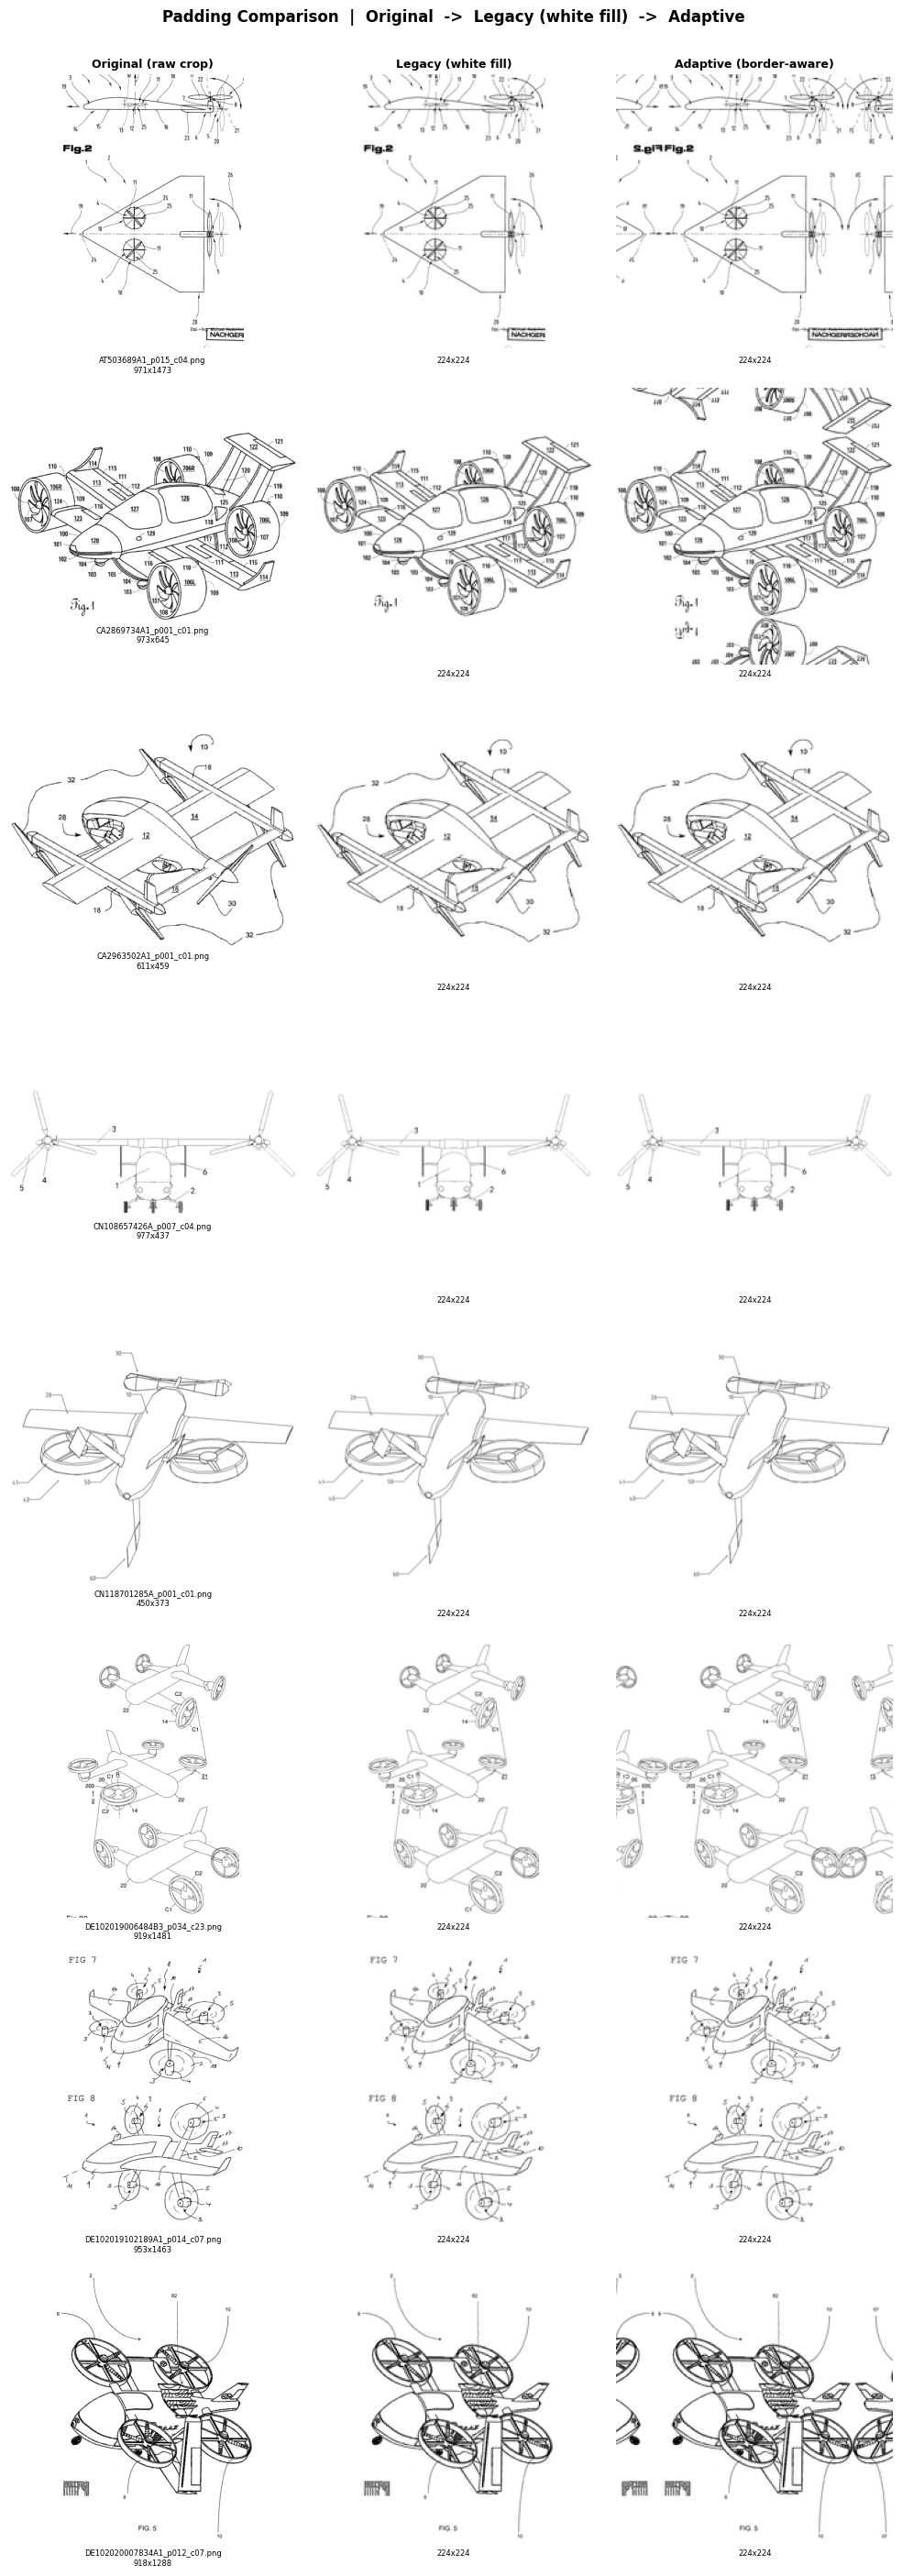

In [4]:
N_PREVIEW    = min(8, len(accepted_paths))
sample_paths = accepted_paths[:N_PREVIEW]

fig, axes = plt.subplots(
    N_PREVIEW, 3,
    figsize=(10, N_PREVIEW * 3.5),
    squeeze=False,
)
fig.suptitle(
    "Padding Comparison  |  Original  ->  Legacy (white fill)  ->  Adaptive",
    fontsize=12, fontweight="bold", y=1.002,
)

for ax, title in zip(axes[0], ["Original (raw crop)", "Legacy (white fill)", "Adaptive (border-aware)"]):
    ax.set_title(title, fontsize=9, fontweight="bold")

for row_idx, crop_path in enumerate(sample_paths):
    img          = Image.open(crop_path).convert("RGB")
    legacy_out   = legacy_padding_resize(img, TARGET_SIZE)
    adaptive_out = adaptive_padding_resize(img, TARGET_SIZE)

    for col_idx, (panel, label) in enumerate([
        (img,          f"{crop_path.name[:40]}\n{img.width}x{img.height}"),
        (legacy_out,   f"{TARGET_SIZE}x{TARGET_SIZE}"),
        (adaptive_out, f"{TARGET_SIZE}x{TARGET_SIZE}"),
    ]):
        ax = axes[row_idx][col_idx]
        ax.imshow(panel)
        ax.set_xlabel(label, fontsize=6)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.tight_layout()
plt.show()

## Quantitative Benchmark

**Border seam std** measures the mean per-channel standard deviation of the outermost 3 px
of the *output* 224×224 image. A lower value means the padding blends smoothly into the
content — a better result for the model.

In [5]:
def _border_seam_std(img224: Image.Image, t: int = 3) -> float:
    """Mean per-channel std dev of the outermost t pixels — proxy for seam harshness."""
    arr    = np.array(img224, dtype=np.float32)
    h, w   = arr.shape[:2]
    strips = [
        arr[:t, :].reshape(-1, 3),
        arr[-t:, :].reshape(-1, 3),
        arr[t:-t, :t].reshape(-1, 3),
        arr[t:-t, -t:].reshape(-1, 3),
    ]
    return float(np.vstack(strips).std(axis=0).mean())


BENCH_N = min(50, len(accepted_paths))
bench_paths = accepted_paths[:BENCH_N]

legacy_times,   adaptive_times   = [], []
legacy_seams,   adaptive_seams   = [], []

for p in tqdm(bench_paths, desc="Benchmarking"):
    img = Image.open(p).convert("RGB")

    t0 = time.perf_counter()
    l_out = legacy_padding_resize(img, TARGET_SIZE)
    legacy_times.append(time.perf_counter() - t0)
    legacy_seams.append(_border_seam_std(l_out))

    t0 = time.perf_counter()
    a_out = adaptive_padding_resize(img, TARGET_SIZE)
    adaptive_times.append(time.perf_counter() - t0)
    adaptive_seams.append(_border_seam_std(a_out))

print(f"\n{'Metric':<32} {'Legacy':>10} {'Adaptive':>10}")
print("-" * 54)
print(f"{'Mean time (ms)':<32} {np.mean(legacy_times)*1000:>9.1f} {np.mean(adaptive_times)*1000:>9.1f}")
print(f"{'Mean border seam std':<32} {np.mean(legacy_seams):>9.2f} {np.mean(adaptive_seams):>9.2f}")
print(f"{'Median border seam std':<32} {np.median(legacy_seams):>9.2f} {np.median(adaptive_seams):>9.2f}")
n_wins = sum(a < l for a, l in zip(adaptive_seams, legacy_seams))
print(f"{'Crops where adaptive wins':<32} {n_wins:>9} / {BENCH_N}")

Benchmarking: 100%|██████████| 50/50 [00:07<00:00,  6.41it/s]


Metric                               Legacy   Adaptive
------------------------------------------------------
Mean time (ms)                        25.9      92.0
Mean border seam std                  6.45     13.61
Median border seam std                5.81      6.58
Crops where adaptive wins                2 / 50


## Production Run

Applies `adaptive_padding_resize` to every accepted crop and writes to `processed/`.
Already-processed files are skipped — safe to re-run.

In [6]:
if FORCE_REPROCESS and PROCESSED_DIR.exists():
    print(f"force_reprocess=True — clearing {PROCESSED_DIR} …")
    shutil.rmtree(PROCESSED_DIR)
    print("  Done.")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

pad_fn = adaptive_padding_resize if PADDING_MODE == "adaptive" else legacy_padding_resize
print(f"Using padding: {PADDING_MODE}  →  {pad_fn.__name__}")

processed_paths = []
skipped = 0
errors  = 0

for crop_path in tqdm(accepted_paths, desc="Processing crops"):
    record_id  = crop_path.name.split("_p")[0]
    patent_out = PROCESSED_DIR / record_id
    patent_out.mkdir(parents=True, exist_ok=True)
    out_path   = patent_out / crop_path.name

    if out_path.exists():
        processed_paths.append(out_path)
        skipped += 1
        continue

    try:
        img    = Image.open(crop_path).convert("RGB")
        result = pad_fn(img, TARGET_SIZE)
        result.save(out_path, "PNG")
        processed_paths.append(out_path)
    except Exception as e:
        print(f"  Error processing {crop_path.name}: {e}")
        errors += 1

print(f"\nDone. {len(processed_paths) - skipped} new | {skipped} skipped | {errors} errors")
print(f"Output: {PROCESSED_DIR}")

Using padding: legacy  →  legacy_padding_resize


Processing crops: 100%|██████████| 100/100 [00:08<00:00, 11.34it/s]


Done. 100 new | 0 skipped | 0 errors
Output: /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/1627_Patents_Processed


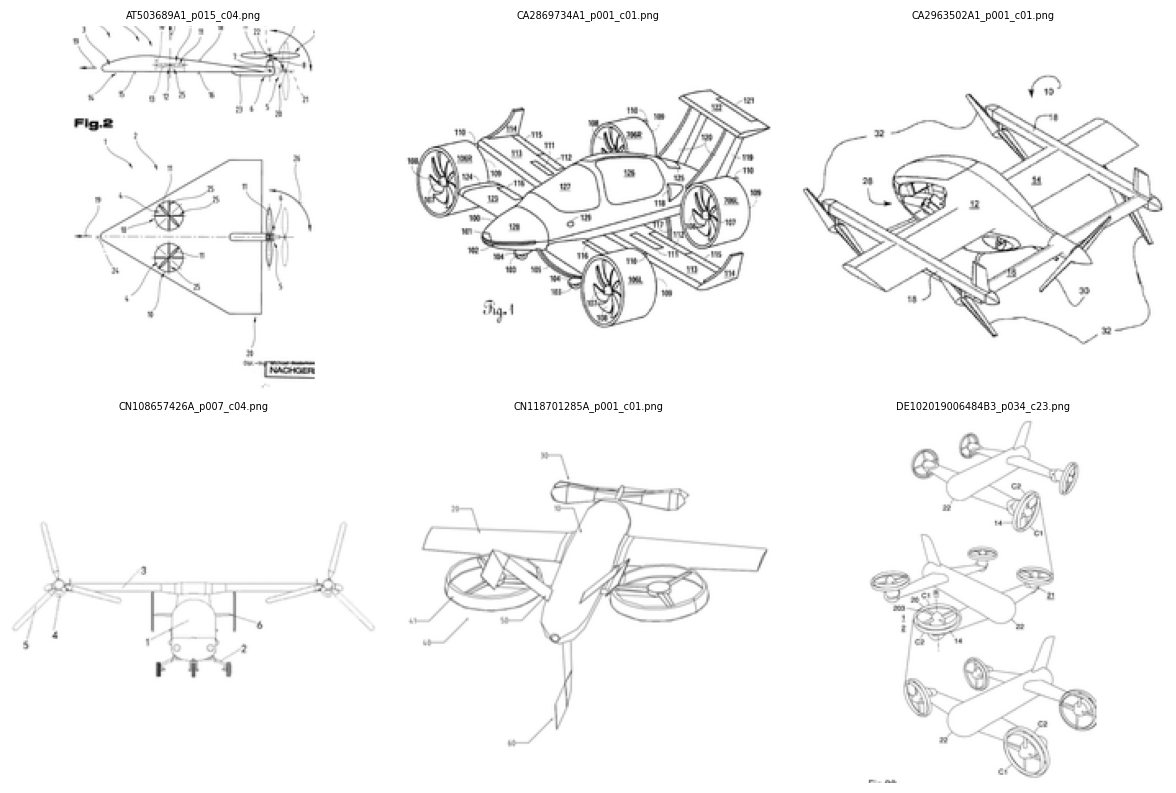

In [7]:
# Quick sanity check — show first 6 processed images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, p in zip(axes.flat, processed_paths[:6]):
    ax.imshow(Image.open(p))
    ax.set_title(Path(p).name[:35], fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# Reload processor module to pick up any code changes without kernel restart
importlib.reload(_proc_mod)
organize_processed = _proc_mod.organize_processed

# Clear old Images Processed output before reorganising
final_dir = Path(cfg["paths"]["final"])
if final_dir.exists():
    shutil.rmtree(final_dir)
    print(f"Cleared old output: {final_dir}")

# Organise into category subfolders with correct naming:
#   Images Processed/shrouded/   {id}_SHR_{CPC}_p003_c01.png
#   Images Processed/open_rotor/ {id}_OPN_{CPC}_p003_c01.png
organize_processed(cfg)

Building CPC map from PatSeer Excel …


/home/vasco/anaconda3/envs/doclayout_yolo/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Loading categories from selected_patents.csv …


Organising final output: 100%|██████████| 100/100 [00:00<00:00, 5936.23it/s]

  open_rotor: 58 images
  shrouded: 42 images
Organise complete: 100 images in /home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed


[PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed/open_rotor/AT503689A1_OPN_B64C290033_p015_c04.png'),
 PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed/open_rotor/CA2869734A1_OPN_B64C290033_p001_c01.png'),
 PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed/open_rotor/CA2963502A1_OPN_B64C290025_p001_c01.png'),
 PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Processed/open_rotor/CN108657426A_OPN_B64C290033_p007_c04.png'),
 PosixPath('/home/vasco/Vasco Workspace/Tese_Vasco_Lnx/Drive_files_to_syncronize/3 - Images Processing & DataSets/1627/Shrouded vs Openrotor/Images Proc